# Trabajo Semanal 2 <img src="imgs/logo_utn_encabezado.png" width="250" align="right"/>
## por Julián Galeano Pinazo
### Teoría de los Circuitos II - Docentes: Mariano Llamedo Soria y David Moharos



#### 1.Establezca la función transferencia pasa bajos $T_{LPF}(s)$ mediante aproximación de máxima planicidad, por caso, Butteworth, de orden 6. Obtenga respuesta de módulo, fase y diagrama de polos y ceros de forma cualitativa.

<img src="imgs/1000103466.jpg" width="800"/>

Se consideró que la pendiente de la respuesta de módulo y el recorrido angular total de la respuesta de fase son: $-n20\frac{dB}{dec} = -120\frac{dB}{dec}$, y $-n\frac{\pi}{2} = -3\pi$, respectivamente

A continuación la verificación de los graficos cualitativos, utilizando _scipy.signal_. La función _buttap_ genera los polos de un filtro por aproximación Butterworth del orden pedido de forma numerica. Luego se utilizan las funciónes _zpk2tf_ para obtener los cocientes de los polinomios de la función transferencia a partir de los polos y ceros, y _TransferFunction_ para tenerla en un objeto y utilizarla con mayor comodidad:

(2,
 array([<Axes: title={'center': 'Magnitude response'}, ylabel='Magnitude [dB]'>,
        <Axes: title={'center': 'Phase response'}, xlabel='Angular frequency [rad/sec]', ylabel='Phase [rad]'>],
       dtype=object))

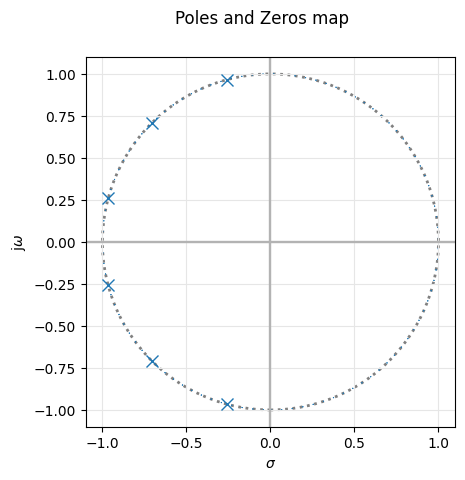

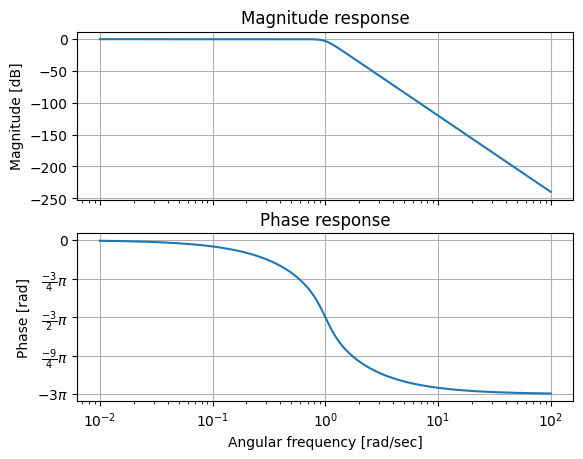

In [9]:
import numpy as np
import scipy.signal as sp
from pytc2.sistemas_lineales import bodePlot, pzmap

z,p,k = sp.buttap(6)
num,den = sp.zpk2tf(z,p,k)
T = sp.TransferFunction(num,den)

pzmap(T)
bodePlot(T)

Se puede ver que se verifican las consideraciones tomadas, los $-120\frac{dB}{dec}$ en la respuesta de amplitud y el recorrido total de $-3\pi$ de la respuesta de fase.

#### 2.Implemente una red normalizada que responda a mediante secciones de segundo orden (SOS) separadas por buffers. En orden creciente de Q (Q1 < Q2 < Q3): $\text{SOS}_1$:Sallen-Key, $\text{SOS}_2$: KHN, $\text{SOS}_3$: MFB

##### $\text{SOS}_1$: Filtro Sallen-Key de $Q=0.5176$

<img src="imgs/Sallen_Key.png" width="500"/>

Sea $\dfrac{G_4}{G_3+G_4} = \dfrac{1}{k}$ y $C_1 = C_2 = C$

Ecuaciones de nodos:
$$
\begin{cases}
(G_1 + G_2 + sC)\,V_a - G_1 V_1 - G_2 V_b - sC\,V_2 = 0 \quad (1)\\[6pt]
(G_2 + sC)\,V_b - G_2 V_2 = 0 \quad (2)\\[6pt]
K\,V_b = V_2
\end{cases}
$$

$$
\Rightarrow V_b = \frac{V_2}{K}
\Rightarrow (2)\;\frac{(G_2 + sC)\,V_2}{K} = G_2 V_2
\Rightarrow V_a = \frac{G_2 + sC}{K\,G_2}\,V_2
$$

$$
\Rightarrow (1)\;\frac{(G_1+G_2+sC)(G_2+sC)}{K\,G_2}\,V_2 - sC\,V_2 - G_1 V_1 - \frac{G_2}{K}\,V_2 = 0
$$

$$
\frac{(G_1+G_2+sC)(G_2+sC) - sC\,K\,G_2 - G_2^2}{K\,G_2}\,V_2 = G_1 V_1
$$

$$
V_2\;\frac{s^2C^2 + sC(G_1 + 2G_2) + G_1 G_2 + G_2^2 - sCK G_2 - G_2^2}{K\,G_2} = G_1 V_1
$$

$$
V_2\;\frac{s^2C^2 + sC\bigl(G_1 + G_2(2-K)\bigr) + G_1 G_2}{K\,G_1 G_2} = V_1
$$

$$
\frac{V_2}{K}\cdot\frac{C^2}{G_1 G_2}
\left[s^2 + s\,\frac{G_1+G_2(2-K)}{C} + \frac{G_1 G_2}{C^2}\right] = V_1
$$

$$
T_1(s) = \frac{V_2}{V_1} =
\frac{K\,\dfrac{G_1 G_2}{C^2}}{s^2 + s\,\dfrac{G_1+G_2(2-K)}{C} + \dfrac{G_1 G_2}{C^2}}
$$

$$
\begin{cases}
\omega_0^2 = \dfrac{G_1 G_2}{C^2} \;\Rightarrow\; \omega_0 = \dfrac{\sqrt{G_1 G_2}}{C}\\[10pt]
\dfrac{\omega_0}{Q} = \dfrac{G_1+G_2(2-K)}{C} \;\Rightarrow Q = \frac{\sqrt{G_1 G_2}}{G_1+G_2(2-K)}
\end{cases}
$$

$$
\text{Con } k = 1 + \frac{G_3}{G_4}
$$

No hace falta verificar esta transferencia con sympy ya que esta red fue resuelta en clase.

##### $\text{SOS}_2$: Filtro de Variables de Estado - KHN de Q = $\frac{\sqrt{2}}{2}$

<img src="imgs/KHN.png" width="700"/>

Se tomará $R_1 = R_2 = R$ por comodidad. Si se toman estas resistencias como no iguales, se puede tener una ganancia en banda de paso $K=-\dfrac{R_2}{R_1}$

$$V_b = -\frac{1}{sCR}\,V_a = -\frac{G}{sC}\,V_a$$

$$V_o = -\frac{1}{sCR}\,V_b = \frac{G^2}{s^2 C^2}\,V_a \quad (1)$$

$$m = 1 + \frac{G_7}{G_6}$$

Ecuaciones de nodos:
$$
\begin{cases}
3G\,V_1 - G\,V_i - G\,V_o - G\,V_a = 0 \quad (2)\\[6pt]
V_1 = V_b\,\dfrac{G_6}{G_6 + G_7} \;\Rightarrow\; V_a = -\dfrac{sC}{G}\left(1 + \dfrac{G_7}{G_6}\right)V_1 \\[6pt]
\end{cases}
$$

$$\overset{(1)}{\Rightarrow}\frac{s^2C^2}{G^2}\,V_o = -\frac{sC}{G}\,m\,V_1$$

$$V_1 = -\frac{G}{sC}\cdot\frac{s^2C^2}{G^2}\cdot\frac{1}{m}\,V_o$$

$$V_1 = -\frac{1}{m}\,\frac{sC}{G}\,V_o$$

Ya teniendo $V_1$ y $V_a$ en función de $V_O$, se sustituye en (2):

$$(2) \quad 3G\left(-\frac{1}{m}\,\frac{sC}{G}\right)V_o - G\,V_i - G\,V_o - G\,\frac{s^2C^2}{G^2}\,V_o = 0$$

$$\left(-\frac{3}{m}\frac{sC}{G} - \frac{s^2C^2}{G^2} - 1\right)V_o = V_i$$

$$-\frac{C^2}{G^2}\left(s^2 + s\,\frac{3G}{Cm} + \frac{G^2}{C^2}\right)V_o = V_i$$

$$\Rightarrow T_2(s) = \frac{V_o}{V_i} = -\dfrac{\dfrac{G^2}{C^2}}{s^2 + s\,\dfrac{3G}{Cm} + \dfrac{G^2}{C^2}}$$

$$
\cases{
    \omega_0^2=\dfrac{G^2}{C^2}\Rightarrow\omega_0=\dfrac{G}{C} \\
    \dfrac{\omega_0}{Q}=\dfrac{3G}{Cm}\Rightarrow Q=\dfrac{m}{3}
    }
$$

A continuación la verificación con Sympy:

In [3]:
import sympy as syp

VI,VO,VA,V1 = syp.symbols("VI,VO,VA,V1")
G,C,M = syp.symbols("G,C,M")
s = syp.symbols("s")
so_1 = syp.solve([
    3*G*V1-G*VI-G*VO-G*VA,
    ((s*C)**2/G**2)*VO-VA,
    ((s*C/G)/M)*VO+V1
    ],
    [VO,VI,VA,V1])

T_KHN = so_1[VO]/so_1[VI]
print(T_KHN)

-G**2*M/(C**2*M*s**2 + 3*C*G*s + G**2*M)


Este resultado verifica el desarrollo realizado.

##### $\text{SOS}_3$: Filtro Multiple Feedback con $C_1 = C_2 = C$ y $Q = 1.932$

<img src="imgs/MFB.png" width="500"/>

Ecuaciones de nodos:
$$
\begin{cases}
(G_1 + G_2 + G_3 + sC_1)\,V_a - G_2\,V_b - G_3\,V_i - G_1\,V_o = 0 \\[6pt]
(G_2 + sC_2)\,V_b - G_2\,V_a - sC_2\,V_o = 0, \text{ con } V_b = 0
\end{cases}
$$

De la segunda ecuación con $V_b = 0$:

$$\cases{
    \Rightarrow (G_1 + G_2 + G_3 + sC_1)\,V_a - G_3\,V_i - G_1\,V_o = 0 \quad (1) \\
    -sC_2\,V_o = G_2\,V_a \;\Rightarrow\; V_a = -\dfrac{sC_2}{G_2}\,V_o
}$$

$$(1) \quad \Rightarrow -(G_1 + G_2 + G_3 + sC_1)\,\frac{sC_2}{G_2}\,V_o - G_1\,V_o - G_3\,V_i = 0$$

$$-\frac{sC_2\,(sC_1 + G_1 + G_2 + G_3) + G_1\,G_2}{G_2}\,V_o = G_3\,V_i$$

$$-V_o\,\frac{s^2C_1 C_2 + sC_2(G_1 + G_2 + G_3) + G_1 G_2}{G_2\,G_3} = V_i$$

$$-V_o\,\frac{C_1 C_2}{G_2 G_3}\left[s^2 + s\,\frac{G_1+G_2+G_3}{C_1} + \frac{G_1 G_2}{C_1 C_2}\right] = V_i$$

$$\Rightarrow T_3(s) = \frac{V_o}{V_i} = -\dfrac{\dfrac{G_2 G_3}{C_1 C_2}}{s^2 + s\,\dfrac{G_1+G_2+G_3}{C_1} + \dfrac{G_1 G_2}{C_1 C_2}}$$

Introduciendo $K = \dfrac{G_3}{G_1}$:

$$\Rightarrow T_3(s) = -\dfrac{K\,\dfrac{G_1 G_2}{C_1 C_2}}{s^2 + s\,\dfrac{G_1+G_2+G_3}{C_1} + \dfrac{G_1 G_2}{C_1 C_2}}$$

$$
\cases{
    \omega_0^2=\dfrac{G_1G_2}{C_1C_2}\Rightarrow\omega_0=\dfrac{\sqrt{G_1G_2}}{\sqrt{C_1C_2}} \\
    \dfrac{\omega_0}{Q}=\dfrac{G_1+G_2+G_3}{C_1}\Rightarrow Q=\dfrac{\sqrt{G_1G_2}}{G_1+G_2+G_3}\sqrt{\dfrac{C_1}{C_2}}
    }
$$

Esta transferencia tambien puede ser verificada utilizando Sympy:

In [4]:
VI,VO,VA = syp.symbols("VI,VO,VA")
G1,G2,G3,C1,C2 = syp.symbols("G1,G2,G3,C1,C2")
s = syp.symbols("s")
so_2 = syp.solve([
    (G1+G2+G3+s*C1)*VA-G3*VI-G1*VO,
    (s*C2)/G2*VO+VA,
    ],
    [VO,VI,VA])

T_MFB = so_2[VO]/so_2[VI]
print(T_MFB)

-G2*G3/(C1*C2*s**2 + C2*G1*s + C2*G2*s + C2*G3*s + G1*G2)


Se puede ver como el resultado verifica la transferencia obtenida.

#### 3. Indique las normas de frecuencia $\Omega_\omega$ e impedancia $\Omega_Z$ adoptadas y los ajustes necesarios para obtener una ganancia de 10 dB en la banda de paso.

En el filtro Sallen-Key, las normas elegidas son: $\Omega_z = {G_1} = {G_2} = G$, $\;\Omega_w = \omega_0$

$$
Q = \frac{1}{3-K} \;\Rightarrow\; \text{si } Q = 0{,}5176 \;\Rightarrow\; K = 3 - \frac{1}{Q} \approx 1{,}07
$$

$$
\text{si } G_4 = G \Rightarrow G_3 = 0,07\,G \text{ para que } K=1,07
$$

$$
\omega_0^2 = \frac{1}{C^2} \;\Rightarrow\; \text{si } \omega_0 = 1,\; C = 1 \Rightarrow
$$

$$
T_1(s) = \frac{K\,\omega_0^2}{s^2\omega_0^2 + s\,\dfrac{\omega_0^2}{Q} + \omega_0^2}
= \frac{K}{s^2 + s\,\dfrac{1}{Q} + 1}
$$

Si se requiere una ganancia total de 10dB en la banda de paso, la forma de calcularla como cociente es:

$$
10dB = 20\, \text{log}_{10}(A_v) \Rightarrow 10^{\dfrac{10 dB}{20}}= A_v = \sqrt{10} =3.162
$$

Como en el filtro Sallen-Key el Q depende directamente de k, esta etapa tiene fijada su ganancia en $A_{v\,1} = 1.07$. Se usará la ultima etapa, el filtro MFB, para añadir los 2.956 de $A_v$ que faltan.

$$
A_{v\,3}= K= \frac{G_3}{G_1} = 2.956 \Rightarrow \text{ si consideramos } G_1 = G_2 =\Omega_Z = G \Rightarrow G_3=2.956\,G
$$

$$
\Rightarrow Q = 1.932 =\frac{G}{2G+2.956\,G} \sqrt{\frac{C_1}{C_2}} \Rightarrow 1.932 = 0.2018 \sqrt{\frac{C_1}{C_2}}
$$

$$
\Rightarrow \sqrt{\frac{C_1}{C_2}} = 9.5738 \Rightarrow C_1 = 91.658 C_2 \text{, pero } C_1C_2 = 1\text{ para }\Omega_\omega = \omega_0
$$

$$
C_2^2=0.0109 \Rightarrow C_2 = 0.10445 \text{ y } C_1 = 9.574
$$

$$
\Rightarrow T_{3}(s)=-\frac{2.956}{s^2+s\frac{4.956}{9.574}+\frac{1}{1.0005}}\text{, que se aproxima muy bien a } T(s) = -\frac{2.956}{s^2+s\frac{1}{1.932}+1}
$$

Ahora queda normalizar el filtro KHN:

$$
T_2(s) = -\dfrac{\dfrac{G^2}{C^2}}{s^2 + s\,\dfrac{3G}{Cm} + \dfrac{G^2}{C^2}}
$$
$$
\text{Sea }\Omega_Z = G \text{ y } \Omega_\omega = \omega_0 \Rightarrow T_2(s) = -\dfrac{1}{s^2 + s\,\dfrac{3}{m} + 1}
$$

$$
Q = \frac{\sqrt{2}}{2} \Rightarrow \sqrt{2} = \frac{3}{m} \Rightarrow m = 3\frac{\sqrt{2}}{2} \Rightarrow 1+\frac{G_7}{G_6} = 3\frac{\sqrt{2}}{2}
$$

$$
\frac{3\sqrt{2}-2}{2} = \frac{G_7}{G_6} = 1.1213 \Rightarrow G_7 = 1.1213G_6 \text{ y si } G_6=1 \Rightarrow G_7=1.1213 \text{ y } Q=1.4142\approx \sqrt{2}
$$

Recapitulando:

$$
T_1(s)\cases{
            G_1=G_2=G_4 = 1 \\
            G_3=0.07 \\
            C_1 = C_2 = 1
            }
\quad
T_2(s)\cases{
            G_1=G_2=G_6=G=1 \\
            G_7=1.1213\\
            C=1
            }
\quad
T_3(s)\cases{
            G_1 = G_2 = 1 \\
            G_3 = 2.956 \\
            C_1 = 9.574, C_2 = 0.10455, C_1C_2 =1
            }
$$


#### 4. Verifique los resultados obtenidos analíticamente mediante simulaciones numéricas y/o simbólicas en Python y circuitales en LTSpice.

Primero se va a realizar la verificación mediante Python. Se van a plantear las transferencias de las tres SOS con los valores calculados en el inciso anterior, y se utilizará la función _sos2tf_analog_ del módulo _pytc2_ para simular la conexión en cascada de estas:

Módulo en w=1/2: 10.002128455280094
Módulo en w=1: 6.991113055022586


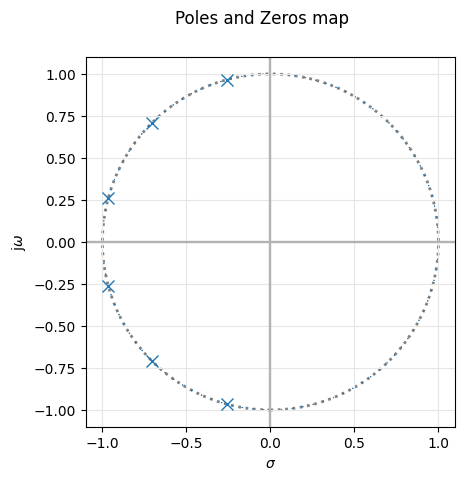

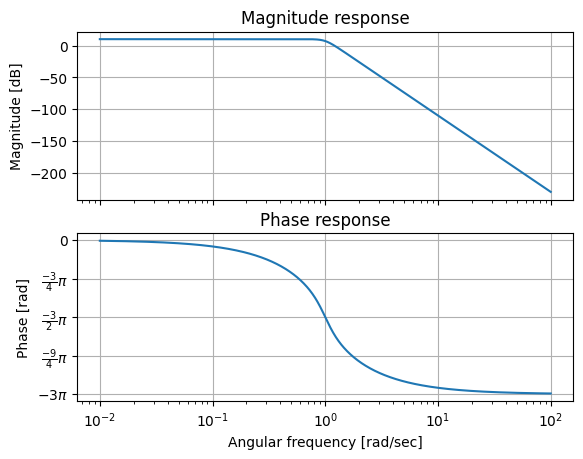

In [8]:
from pytc2.sistemas_lineales import sos2tf_analog

#Variables de la SOS1 - Sallen-Key
G_SK = 1
G_4_SK = 0.07
K_SK = 1+G_4_SK/G_SK
C_SK = 1

#Variables de la SOS2 - KHN
G_KHN = 1
G_7_KHN = 1.1213
M_KHN = 1+G_7_KHN/G_KHN
C_KHN = 1

#Variables de la SOS3 - Multiple Feedback
G_MFB = 1
G_3_MFB = 2.956
K_MFB = G_3_MFB/G_MFB
C_1_MFB = 9.574
C_2_MFB = 0.10455

SOS = np.array([[0,0,K_SK*(G_SK**2)/(C_SK**2),1,G_SK*(3-K_SK)/C_SK,(G_SK**2)/(C_SK**2)],
                [0,0,-(G_KHN**2)/(C_KHN**2),1,3*G_KHN/(C_KHN*M_KHN),(G_KHN**2)/(C_KHN**2)],
                [0,0,-K_MFB*(G_MFB**2)/(C_1_MFB*C_2_MFB),1,(2*G_MFB+G_3_MFB)/C_1_MFB,(G_MFB**2)/(C_1_MFB*C_2_MFB)]])

TF = sos2tf_analog(SOS)
pzmap(TF)
bodePlot(TF)

w, TF_w0 = sp.freqresp(TF,w=[0.1,1])
print(f"Módulo en w=1/2: {20*np.log10(np.abs(TF_w0[0]))}")
print(f"Módulo en w=1: {20*np.log10(np.abs(TF_w0[1]))}")

Se puede ver que los resultados son los mismos que los obtenidos en el primer punto mediante la función _buttap_ de _scipy.signal_, pero con +10dB en la banda de paso y +7dB en $\omega_0$, por lo que los calculos hechos quedan verificados.

A continuación las simulaciones circuitales en LTSpice. Se eligió una norma de frecuencia $\Omega_\omega = 1\text{Hz}$ ya que no se puede visualizar el eje de frecuencias en radianes.

<img src="imgs/ltspice_circ.png" width="1100"/>

<img src="imgs/ltspice_sim_cursor.png" width="300" align="right"/>
<img src="imgs/ltspice_sim.png" width="750"/>

Los resultados coinciden con las verificaciones de Python.

#### EXTRA: Se pide implementar una función transferencia Butter pero de orden 7. ¿Puede reutilizar las SOSs obtenidas anteriormente? ¿Bastaría con cascadear una sección de primer orden?

Las aproximaciones por maxima planicidad resultan en polos equiespaciados angularmente a traves de una circunferencia de radio $\omega_0$ centrada en el origen, por lo que al aumentar el orden del filtro implica una nueva separación entre los polos, lo que cambia el ángulo individual de cada uno y por lo tanto, su factor de calidad $Q$. En un Butterworth de orden 7, la separación entre polos ya no sería de $\dfrac{\pi}{6}$, si no que sería de $\dfrac{\pi}{7}$. Como siguen siendo polos complejos conjugados, pueden usarse las topologías de las SOS anteriores, pero deberán ser diseñadas para un nuevo $Q$. Las transferencias de maxima planicidad de orden impar tienen la particularidad de que uno de los polos solo tiene componente real, por lo que habría que añadir una sección de primer orden, pero también habría que recalcular el $Q$ de cada una de las SOS.

Puntualmente, el Q para cada una de las SOS debería ser:
$$
\cases{
    \phi_1 = 0 \Rightarrow Q_1=0.5 \text{ (Seccion de primer orden)}\\
    \\
    \phi_2 = \dfrac{\pi}{7} \Rightarrow Q_2=0.555 \\
    \\
    \phi_3 = \dfrac{2\pi}{7} \Rightarrow Q_3=0.802 \\
    \\
    \phi_4 = \dfrac{3\pi}{7} \Rightarrow Q_4=2.247 \\
    }
$$